# PIXEL Model Explainability

This notebook implements attention map explainability for PIXEL models using methods adapted from the Transformer-MM explainability approach.


In [1]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch
import numpy as np
import cv2

import sys
# Add project path
sys.path.append('/home/bens/pixel')

from src.pixel import (
    PangoCairoTextRenderer,
    get_transforms,
    Modality
)
from src.pixel.models.pixel.modeling_pixel_interpretable import (
    InterpretablePIXELForSequenceClassification
)
from src.pixel.utils.interpretability import (
    generate_relevance,
    generate_visualization
)

from src.pixel.data import BARECDataset
from tqdm import tqdm

print("✅ Imports successful!")
print(f"🔧 Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

%load_ext autoreload
%autoreload 2


/opt/anaconda3/envs/pixel-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports successful!
🔧 Device: CUDA


## Load Model and Renderer

In [2]:
# Configuration
MODEL_PATH = "../runs/pixel-base-arabic-default-256-32-1-2.5e-05-5-42/"  # Use base model for testing
MAX_SEQ_LENGTH = 256
NUM_LABELS = 19  # For BAREC dataset
DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"

# Load text renderer
print("🔧 Loading text renderer...")
renderer = PangoCairoTextRenderer.from_pretrained(
    MODEL_PATH,
    rgb=False
)
renderer.max_seq_length = MAX_SEQ_LENGTH

# Load interpretable model
print("🔧 Loading interpretable PIXEL model...")
model = InterpretablePIXELForSequenceClassification.from_pretrained(
    MODEL_PATH,
    num_labels=NUM_LABELS
)
model.to(DEVICE)
model.eval()

print(f"✅ Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"✅ Renderer loaded with max_seq_length: {renderer.max_seq_length}")

🔧 Loading text renderer...
🔧 Loading interpretable PIXEL model...


/opt/anaconda3/envs/pixel-env/lib/python3.9/site-packages/transformers/modeling_utils.py:1439: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(resolved

✅ Model loaded: 86,451,475 parameters
✅ Renderer loaded with max_seq_length: 256


## Prepare Text Input

In [3]:
# Configuration for dataset
DATASET_NAME = "CAMeL-Lab/BAREC-Shared-Task-2025-sent"
SPLIT = "test"  # Use validation split for explainability analysis
PROCESSING_CONFIG = "arabic-default"  # Match your model's processing config

print(f"📊 Loading BAREC dataset...")
print(f"   Dataset: {DATASET_NAME}")
print(f"   Split: {SPLIT}")
print(f"   Processing config: {PROCESSING_CONFIG}")

# Get transforms for image preprocessing
transforms = get_transforms(
    do_resize=True,
    size=(renderer.pixels_per_patch, renderer.pixels_per_patch * renderer.max_seq_length),
)

# Create BAREC dataset
dataset = BARECDataset(
    dataset_name=DATASET_NAME,
    processor=renderer,
    modality=Modality.IMAGE,
    max_seq_length=MAX_SEQ_LENGTH,
    split=SPLIT,
    transforms=transforms,
    processing_config_name=PROCESSING_CONFIG,
    inference=True,  # Include IDs for tracking
    # sample_size=100  # Limit to 100 samples for testing
)

print(f"✅ Dataset loaded: {len(dataset)} examples")



📊 Loading BAREC dataset...
   Dataset: CAMeL-Lab/BAREC-Shared-Task-2025-sent
   Split: test
   Processing config: arabic-default


100%|██████████| 2040/2040 [00:00<00:00, 5760.93it/s]
/home/bens/pixel/src/pixel/data/datasets/barec_dataset.py:64: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "attention_mask": torch.tensor(attention_mask, dtype=torch.long),


✅ Dataset loaded: 2040 examples


## Batch Analysis Setup

In [4]:
# Setup for analyzing multiple samples
def get_correct_samples(dataset, model, num_samples=10):
    correct_examples = [] 

    print("🔍 Finding correct samples for analysis...")
    
    # Sample a subset for analysis (to avoid processing entire dataset)
    indices = torch.randperm(len(dataset))#[:min(100, len(dataset))]
    
    for idx in tqdm(indices):
        sample = dataset[idx]
        inputs = {
            "pixel_values": sample["pixel_values"].unsqueeze(0).to(DEVICE),
            "attention_mask": sample["attention_mask"].unsqueeze(0).to(DEVICE)
        }
        
        with torch.no_grad():
            outputs = model(**inputs)
            predicted_class = torch.argmax(outputs.logits, dim=-1).item()
            probabilities = torch.softmax(outputs.logits, dim=-1)[0]
            confidence = probabilities[predicted_class].item()
        
        is_correct = predicted_class == sample['label']
        if is_correct:
            correct_examples.append(idx)
            if len(correct_examples) >= num_samples:
                break

    return correct_examples

# Find correct samples
correct_examples = get_correct_samples(dataset, model, num_samples=10)
len(correct_examples)

🔍 Finding correct samples for analysis...


  0%|          | 0/2040 [00:00<?, ?it/s]

  1%|▏         | 27/2040 [00:00<00:34, 58.78it/s]


10

# Find Interesting Samples

In [13]:
# Function to analyze different samples interactively
def analyze_sample(sample_idx: int):
    """Analyze a specific sample from the dataset"""
    sample = dataset[sample_idx]
    original_sentence = dataset.examples[sample_idx].sentence
    
    # Prepare inputs
    inputs = {
        "pixel_values": sample["pixel_values"].unsqueeze(0).to(DEVICE),
        "attention_mask": sample["attention_mask"].unsqueeze(0).to(DEVICE)
    }
    
    # Get prediction
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_class = torch.argmax(outputs.logits, dim=-1).item()
        probabilities = torch.softmax(outputs.logits, dim=-1)[0]
        confidence = probabilities[predicted_class].item()
    
    return inputs, sample, original_sentence

sample_idx = correct_examples[1]
sample = dataset[sample_idx]
# Analyze the current sample
inputs, current_sample, original_sentence = analyze_sample(sample_idx)

## Generate Model Predictions

In [14]:
# Get model predictions
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1)
    predicted_class = torch.argmax(logits, dim=-1)

print(f"🎯 Predicted class: {predicted_class.item()}")
print(f"📊 Top 3 probabilities:")

# Show top 3 predictions
top_probs, top_indices = torch.topk(probabilities[0], k=3)
for i, (prob, idx) in enumerate(zip(top_probs, top_indices)):
    print(f"   {i+1}. Class {idx.item()}: {prob.item():.4f} ({prob.item()*100:.1f}%)")

🎯 Predicted class: 11
📊 Top 3 probabilities:
   1. Class 11: 0.2043 (20.4%)
   2. Class 9: 0.1751 (17.5%)
   3. Class 7: 0.1602 (16.0%)


## Generate Attention Visualization

In [15]:
# Generate relevance map
print("🔍 Generating attention relevance map...")
relevance = generate_relevance(model, inputs, index=predicted_class.item())
print(f"✅ Relevance map generated: {relevance.shape}")

# Create visualization
print("🎨 Creating visualization...")
image_hw = renderer.pixels_per_patch * int(np.sqrt(inputs['pixel_values'].shape[-1] // renderer.pixels_per_patch))
patch_size = renderer.pixels_per_patch

visualization = generate_visualization(
    model=model,
    inputs=inputs,
    image_hw=image_hw,
    patch_size=patch_size,
    class_index=predicted_class.item()
)

print(f"✅ Visualization generated: {visualization.shape}")

🔍 Generating attention relevance map...
✅ Relevance map generated: torch.Size([256])
🎨 Creating visualization...
✅ Visualization generated: (256, 256, 3)


## Display Results

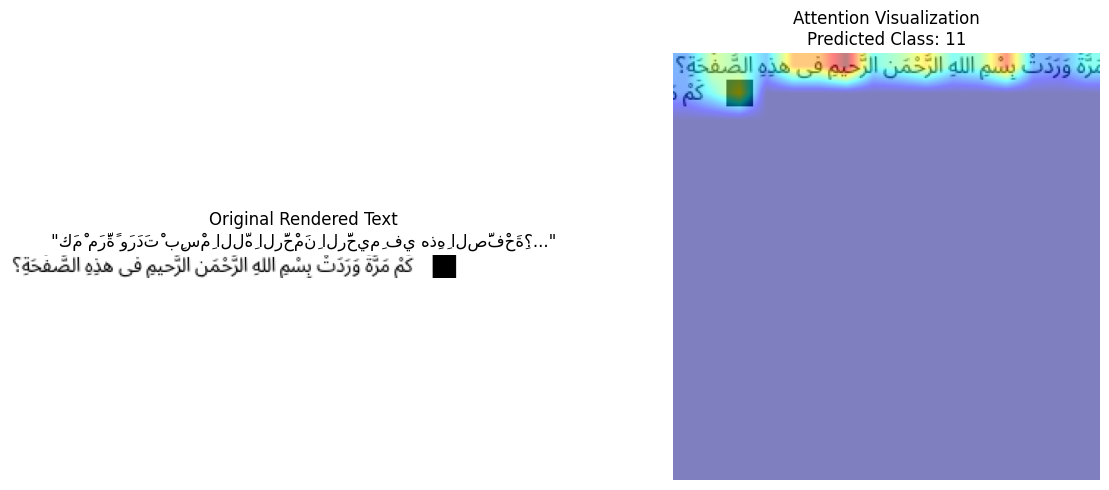

🎨 Visualization complete!


In [16]:
# Display original image and attention visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original rendered text image
original_img = current_sample["pixel_values"].permute(1, 2, 0).cpu().numpy().squeeze()[:,:400,:]
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title(f'Original Rendered Text\n"{original_sentence[:100]}..."')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(visualization, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Attention Visualization\nPredicted Class: {predicted_class.item()}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("🎨 Visualization complete!")